## Doprinos 3

In [13]:
referenca_eng = [
    "Artificial intelligence is a field of computer science focused on developing systems capable of solving problems, making decisions, and understanding human speech.",
    "Speech recognition technologies are becoming increasingly important in modern applications such as virtual assistants and automated customer support.",
    "Machine learning algorithms can improve their performance by analyzing large amounts of data and identifying hidden patterns."
]

referenca_sr = [
    "Veštačka inteligencija je oblast računarskih nauka koja se bavi razvojem sistema sposobnih za rešavanje problema, donošenje odluka i razumevanje ljudskog govora.",
    "Tehnologije za automatsko prepoznavanje govora postaju sve značajnije u savremenim aplikacijama kao što su virtuelni asistenti i korisnička podrška.",
    "Algoritmi mašinskog učenja mogu unaprediti svoje performanse analizom velikih količina podataka i pronalaženjem skrivenih obrazaca."
]

In [14]:
from faster_whisper import WhisperModel
from jiwer import wer
import pandas as pd
import numpy as np

In [15]:
model = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

In [16]:
audio_eng = [
    "audio/engleski.wav",
    "audio/engleski1.wav",
    "audio/engleski2.wav"
]

audio_sr = [
    "audio/srpski.wav",
    "audio/srpski1.wav",
    "audio/srpski2.wav"
]

In [17]:
rezultati_eng = []

for fajl, referenca in zip(audio_eng, referenca_eng):

    segments, info = model.transcribe(
        fajl,
        language="en"
    )

    transkript = ""

    for segment in segments:
        transkript += segment.text + " "

    greska = wer(
        referenca.lower().strip(),
        transkript.lower().strip()
    )

    rezultati_eng.append(greska)

    print("=" * 60)
    print(fajl)
    print("REFERENCA:")
    print(referenca)
    print("TRANSKRIPT:")
    print(transkript)
    print("WER:", round(greska * 100, 2), "%")

audio/engleski.wav
REFERENCA:
Artificial intelligence is a field of computer science focused on developing systems capable of solving problems, making decisions, and understanding human speech.
TRANSKRIPT:
 Artificial intelligence is a field of computer science focused on developing systems capable  of solving problems, making decisions, and understanding human speech. 
WER: 0.0 %
audio/engleski1.wav
REFERENCA:
Speech recognition technologies are becoming increasingly important in modern applications such as virtual assistants and automated customer support.
TRANSKRIPT:
 Speech recognition technologies are becoming increasingly important in modern applications,  such as virtual assistance and automated customer support. 
WER: 11.11 %
audio/engleski2.wav
REFERENCA:
Machine learning algorithms can improve their performance by analyzing large amounts of data and identifying hidden patterns.
TRANSKRIPT:
 Machine learning algorithms can improve their performance by analyzing large amounts o

In [18]:
rezultati_sr = []

for fajl, referenca in zip(audio_sr, referenca_sr):

    segments, info = model.transcribe(
        fajl,
        language="sr"
    )

    transkript = ""

    for segment in segments:
        transkript += segment.text + " "

    greska = wer(
        referenca.lower().strip(),
        transkript.lower().strip()
    )

    rezultati_sr.append(greska)

    print("=" * 60)
    print(fajl)
    print("REFERENCA:")
    print(referenca)
    print("TRANSKRIPT:")
    print(transkript)
    print("WER:", round(greska * 100, 2), "%")

audio/srpski.wav
REFERENCA:
Veštačka inteligencija je oblast računarskih nauka koja se bavi razvojem sistema sposobnih za rešavanje problema, donošenje odluka i razumevanje ljudskog govora.
TRANSKRIPT:
 Veštočka inteligencija je oblast računarskih nauka koje se bavi razvojim sistem asposobnih za rešavanje problema,  donošenje odluka i razumevanje ludsko govor. 
WER: 33.33 %
audio/srpski1.wav
REFERENCA:
Tehnologije za automatsko prepoznavanje govora postaju sve značajnije u savremenim aplikacijama kao što su virtuelni asistenti i korisnička podrška.
TRANSKRIPT:
 Technologije za automacko prepoznavanje govara postaju sve znacenije u savremenim aplikacijama kao što su virtuelni, asistenti i koristnička podraška. 
WER: 36.84 %
audio/srpski2.wav
REFERENCA:
Algoritmi mašinskog učenja mogu unaprediti svoje performanse analizom velikih količina podataka i pronalaženjem skrivenih obrazaca.
TRANSKRIPT:
 Algoritmi mašinskog učenja mogu u naprediti svoje performanse analizom velikih količina podat

In [19]:
prosek_eng = np.mean(rezultati_eng)
prosek_sr = np.mean(rezultati_sr)

print("Prosečan WER engleski:",
      round(prosek_eng * 100, 2), "%")

print("Prosečan WER srpski:",
      round(prosek_sr * 100, 2), "%")

Prosečan WER engleski: 3.7 %
Prosečan WER srpski: 30.06 %


In [20]:
tabela_doprinos3 = pd.DataFrame({
    "Jezik": [
        "engleski",
        "srpski"
    ],
    "Prosečan WER [%]": [
        round(prosek_eng * 100, 2),
        round(prosek_sr * 100, 2)
    ]
})

tabela_doprinos3

,Jezik,Prosečan WER [%]
0,engleski,3.70
1,srpski,30.06


In [21]:
tabela_doprinos3.to_csv(
    "rezultati/doprinos3_srpski_engleski.csv",
    index=False,
    encoding="utf-8-sig"
)

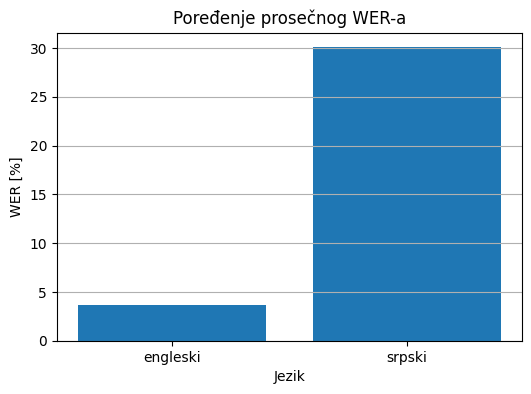

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    tabela_doprinos3["Jezik"],
    tabela_doprinos3["Prosečan WER [%]"]
)

plt.ylabel("WER [%]")
plt.xlabel("Jezik")
plt.title("Poređenje prosečnog WER-a")

plt.grid(axis="y")
plt.show()

## Komentar rezultata

Rezultati prikazani u tabeli pokazuju značajnu razliku u kvalitetu automatske transkripcije između engleskog i srpskog jezika. Analiza je izvršena na tri audio zapisa za svaki jezik, a kao metrika kvaliteta korišćena je WER (Word Error Rate) stopa greške.

Za engleski jezik ostvarena je prosečna vrednost WER metrike od 3.70%, što ukazuje na veoma visok nivo tačnosti prepoznavanja govora. Kod dva od tri testirana audio zapisa model je ostvario WER od 0.00%, odnosno transkript se u potpunosti poklopio sa referentnim tekstom. Jedina uočena greška pojavila se u drugom audio zapisu, gde je model prepoznao izraz „virtual assistance“ umesto „virtual assistants“, što je dovelo do blagog povećanja prosečne stope greške.

Za srpski jezik ostvarena je prosečna vrednost WER metrike od 30.06%, što predstavlja znatno slabiji rezultat u odnosu na engleski jezik. U generisanim transkriptima primećene su različite vrste grešaka, uključujući pogrešno prepoznavanje pojedinih reči, promene gramatičkih oblika, izostavljanje delova reči i fonetski slične zamene. Primeri takvih grešaka su „Veštočka“ umesto „Veštačka“, „razvojim“ umesto „razvojem“, „govara“ umesto „govora“ i „obrazac“ umesto „obrasaca“.

Dobijeni rezultati potvrđuju da model ostvaruje znatno bolje performanse na engleskom jeziku nego na srpskom. Ovakvo ponašanje je očekivano jer su Whisper modeli trenirani na veoma velikim količinama engleskog govora, dok je zastupljenost srpskog jezika u dostupnim skupovima podataka značajno manja. Zbog toga model poseduje bolje jezičke reprezentacije i veću sposobnost korektnog prepoznavanja engleskog govora.

Na osnovu sprovedenog eksperimenta može se zaključiti da je jezik audio zapisa značajan faktor koji utiče na kvalitet automatskog prepoznavanja govora. Na korišćenom skupu podataka engleski jezik ostvario je prosečan WER od svega 3.70%, dok je za srpski jezik zabeležen prosečan WER od 30.06%. Ovi rezultati ukazuju da Faster-Whisper model može veoma precizno da transkribuje engleski govor, dok kod srpskog jezika i dalje postoji prostor za unapređenje tačnosti prepoznavanja.
pe greške.